<a href="https://colab.research.google.com/github/cameronliddle/ThesisAIDetection/blob/main/PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre Processing

In [ ]:
import os
import shutil
import random
from pathlib import Path

# Corrected source paths
base_source = '/content/drive/MyDrive/Thesis/Processed_Dataset'
train_real = f'{base_source}/Train/REAL'
train_fake = f'{base_source}/Train/FAKE'
val_real = f'{base_source}/Validation/REAL'
val_fake = f'{base_source}/Validation/FAKE'

# Destination path for new split
base_dest = f'{base_source}/resplit_dataset'
splits = ['train', 'val', 'test']
classes = ['REAL', 'FAKE']

# Split ratio
split_ratio = {
    'train': 0.7,
    'val': 0.15,
    'test': 0.15
}

# Get all images (filtered by extension)
def get_all_images(*folders):
    image_extensions = ['.jpg', '.jpeg', '.png', '.webp']
    images = []
    for folder in folders:
        for img in Path(folder).glob('*'):
            if img.suffix.lower() in image_extensions:
                images.append(img)
    return images

real_images = get_all_images(train_real, val_real)
fake_images = get_all_images(train_fake, val_fake)

print(f"REAL total: {len(real_images)}")
print(f"FAKE total: {len(fake_images)}")

# Shuffle
random.shuffle(real_images)
random.shuffle(fake_images)

# Split function
def split_images(images, split_ratio):
    total = len(images)
    n_train = int(total * split_ratio['train'])
    n_val = int(total * split_ratio['val'])
    return (
        images[:n_train],  # train
        images[n_train:n_train + n_val],  # val
        images[n_train + n_val:]  # test
    )

real_train, real_val, real_test = split_images(real_images, split_ratio)
fake_train, fake_val, fake_test = split_images(fake_images, split_ratio)

# Mapping
data_map = {
    'REAL': [real_train, real_val, real_test],
    'FAKE': [fake_train, fake_val, fake_test]
}

# Create folders and copy images
for split, split_idx in zip(splits, [0, 1, 2]):
    for label in classes:
        dest_dir = os.path.join(base_dest, split, label)
        os.makedirs(dest_dir, exist_ok=True)
        for img_path in data_map[label][split_idx]:
            shutil.copy(str(img_path), dest_dir)

print(" Done! New dataset created at:", base_dest)


REAL total: 10613
FAKE total: 10000
✅ Done! New dataset created at: /content/drive/MyDrive/Thesis/Processed_Dataset/resplit_dataset


In [ ]:
import os

# Path to your new dataset
base_path = '/content/drive/MyDrive/Thesis/Processed_Dataset/resplit_dataset'

# Classes and splits
splits = ['train', 'val', 'test']
classes = ['REAL', 'FAKE']

# Count images
for split in splits:
    print(f'\n {split.upper()}')
    for cls in classes:
        cls_path = os.path.join(base_path, split, cls)
        count = len(os.listdir(cls_path))
        print(f'  {cls}: {count} images')



📂 TRAIN
  REAL: 6379 images
  FAKE: 6216 images

📂 VAL
  REAL: 1541 images
  FAKE: 1460 images

📂 TEST
  REAL: 1542 images
  FAKE: 1464 images


📊 Image Counts:
Train - REAL: 6379 images
Train - FAKE: 6216 images
Val - REAL: 1541 images
Val - FAKE: 1460 images
Test - REAL: 1542 images
Test - FAKE: 1464 images

🔍 Sample REAL Images:


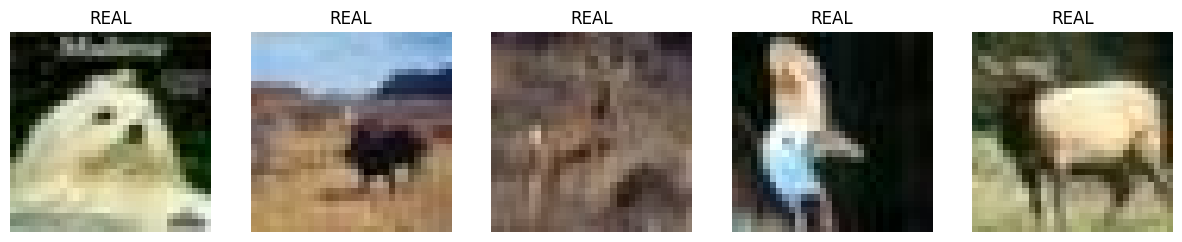


🔍 Sample FAKE Images:


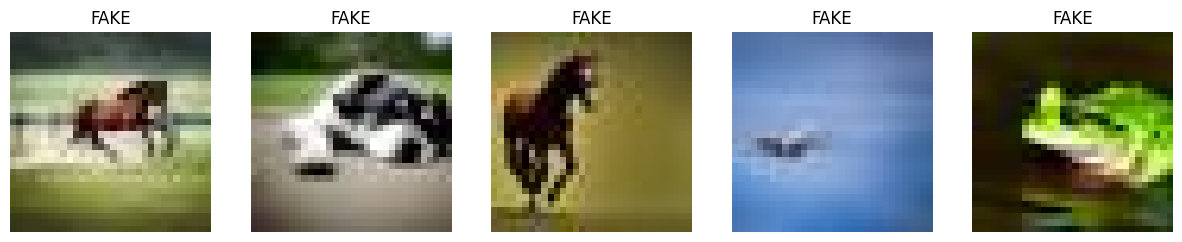

Found 12595 images belonging to 2 classes.
Found 3001 images belonging to 2 classes.
Found 3006 images belonging to 2 classes.

✅ All Keras DataLoaders Ready!


In [ ]:
import os
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

# New dataset location
base_dir = '/content/drive/MyDrive/Thesis/Processed_Dataset/resplit_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# ===  Count Images in Each Split
print("📊 Image Counts:")
for split in ['train', 'val', 'test']:
    for label in ['REAL', 'FAKE']:
        folder = os.path.join(base_dir, split, label)
        count = len(os.listdir(folder))
        print(f"{split.capitalize()} - {label}: {count} images")

# ===  Visualize Random Samples
def show_random_images(folder_path, label):
    images = os.listdir(folder_path)
    selected = random.sample(images, 5)
    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(selected):
        img = load_img(os.path.join(folder_path, img_name))
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

print("\n Sample REAL Images:")
show_random_images(os.path.join(train_dir, 'REAL'), 'REAL')

print("\n Sample FAKE Images:")
show_random_images(os.path.join(train_dir, 'FAKE'), 'FAKE')

# === ⚙️ Data Generators (Keras)
batch_size = 32
img_size = (128, 128)

# Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Validation
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Test
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("\n All Keras DataLoaders Ready!")
